# N Qubit Scaling Tests
# Scaling Superposition Dynamically
**Objective:** Write a scalable Python function to generate $n$-qubit superpositions and observe how the complexity scales exponentially.

In [17]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from IPython.display import display

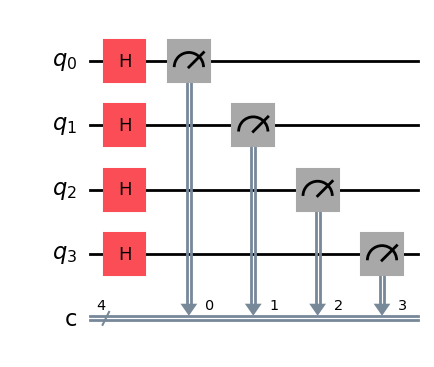

In [18]:
def create_superposition_circuit(n: int) -> QuantumCircuit:
    """Generates an n-qubit circuit in uniform superposition."""
    qc = QuantumCircuit(n, n)
    for i in range(n):
        qc.h(i)
    qc.measure(range(n), range(n))
    return qc

# Test the function visually for n=4
test_qc = create_superposition_circuit(4)
display(test_qc.draw('mpl'))

In [19]:
sampler = StatevectorSampler()
shots = 2000

# Loop through 2 to 5 qubits to see the exponential growth of states
for n in range(2, 6):
    qc = create_superposition_circuit(n)
    
    # Run the circuit
    job = sampler.run([qc], shots=shots)
    counts = job.result()[0].data.c.get_counts()
    
    # Calculate expected vs actual
    expected_states = 2**n
    actual_states = len(counts)
    
    print(f"Qubits: {n} | Expected States: {expected_states} | Measured States: {actual_states}")

Qubits: 2 | Expected States: 4 | Measured States: 4
Qubits: 3 | Expected States: 8 | Measured States: 8
Qubits: 4 | Expected States: 16 | Measured States: 16
Qubits: 5 | Expected States: 32 | Measured States: 32
